In [1]:
from typing import TypedDict 
from langgraph.graph import StateGraph  , START , END 

In [2]:
class AgentState(TypedDict):
    number1 : int 
    operation : str 
    number2 : int
    finalNumber : int 


In [3]:
def adder(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""
    state['finalNumber'] = state['number1'] + state['number2']
    return state 

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts 2 numbers"""
    state['finalNumber'] = state['number1'] - state['number2']
    return state 

#now defining a router node which decide which node to go next based on the operation
def decide_next_node(state: AgentState) -> str:
    """This node decides which node to go to next"""
    
    if state['operation'] == 'add':
        return 'additon_operation'
    
    elif state['operation'] == 'subtract':
        return 'subtraction_operation'

In [4]:
graph = StateGraph(AgentState)
graph.add_node("add_node" , adder)
graph.add_node("subtract_node" , subtractor)
graph.add_node("router" , lambda state : state)#pass through function , no changes in state that i why we allow the state to pass as it is , this state just perform the decision and selects the path based on the operation 

graph.add_edge(START , "router")
graph.add_conditional_edges(
    "router", 
                            # Name of the source node (current node)
                            # After "router" finishes execution,
                            # LangGraph will evaluate which edge to take next
    decide_next_node,
                            # A function that receives the current state
                            # and RETURNS A STRING (the routing key)
                            #
                            # Example return values:
                            #   "additon_operation"
                            #   "subtraction_operation"
    {
        
        "additon_operation" : "add_node",
                                                # If router returns this key,
                                                # execution moves to add_node
        "subtraction_operation" : "subtract_node"
        #else to this 
    }
)

graph.add_edge("add_node" , END)
graph.add_edge("subtract_node" , END)
app = graph.compile()

In [5]:
# ---------------------------------------------------------
# add_conditional_edges allows dynamic routing in LangGraph
# ---------------------------------------------------------
# Instead of always going to a fixed next node,
# the graph decides the next node at runtime
# based on the current state.

# ---------------------------------------------------------
# Example router function
# ---------------------------------------------------------
# def decide_next_node(state):
#     if state["operation"] == "add":
#         return "additon_operation"
#     else:
#         return "subtraction_operation"

# ---------------------------------------------------------
# Execution flow example
# ---------------------------------------------------------
# router(state) runs first
# decide_next_node(state) is called
#
# If it returns "additon_operation":
#     router --> add_node
#
# If it returns "subtraction_operation":
#     router --> subtract_node

# ---------------------------------------------------------
# Important rules
# ---------------------------------------------------------
# 1. The router function MUST return a string
# 2. The returned string MUST exist as a key in the mapping
# 3. The mapped value MUST be a valid node name
# 4. Node names are strings, not functions

# ---------------------------------------------------------
# Mental model
# ---------------------------------------------------------
# This is equivalent to an if/else switch inside the graph,
# but controlled by graph state instead of direct code flow.


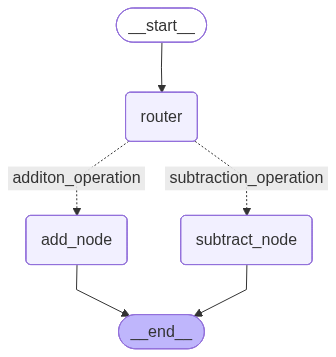

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
intitial_state_1= AgentState(number1 = 10 , operation = "add" , number2 = 5)
print(app.invoke(intitial_state_1))

{'number1': 10, 'operation': 'add', 'number2': 5, 'finalNumber': 15}


In [8]:
intitial_state_2 = AgentState(number1 = 10 , operation = "subtract" , number2 = 5)
print(app.invoke(intitial_state_2))

{'number1': 10, 'operation': 'subtract', 'number2': 5, 'finalNumber': 5}


-------------------------

In [17]:
class AgentState(TypedDict):
    number1 : int 
    operation1 : str 
    number2 : int 
    finalNumber1: int
    number3 : int 
    operation2 : str 
    number4 : int 
    finalNumber2 : int 

def add_node1(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""
    state['finalNumber1'] = state['number1'] + state['number2']
    return state 

def add_node2(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""
    state['finalNumber2'] = state['number3'] + state['number4']
    return state 

def subtract_node1(state : AgentState) -> AgentState:
    """This node subtracts 2 numbers"""
    state['finalNumber1'] = state['number1'] - state['number2']
    return state 

def subtract_node2(state : AgentState) -> AgentState:
    """This node subtracts 2 numbers"""
    state['finalNumber2'] = state['number3'] - state['number4']
    return state 

def router1(state: AgentState) -> str:
    if state['operation1'] == 'add':
        return "additon_operation1"
    else:
        return "subtract_operation1"

def router2(state: AgentState) -> str:
    if state['operation2'] == 'add':
        return "additon_operation2"
    else:
        return "subtract_operation2"


In [18]:
graph2 = StateGraph(AgentState)
graph2.add_node("add_node1" , add_node1)
graph2.add_node("add_node2" , add_node2)
graph2.add_node("subtract_node1" , subtract_node1)
graph2.add_node("subtract_node2" , subtract_node2)
graph2.add_node('router1' , lambda state : state)
graph2.add_node('router2' , lambda state : state)

graph2.add_edge(START , 'router1')
graph2.add_conditional_edges(
    'router1',
    router1,
    {
        "additon_operation1" : "add_node1",
        "subtract_operation1" : "subtract_node1"
    }
)

graph2.add_edge("add_node1" , "router2")
graph2.add_edge("subtract_node1" , "router2")
graph2.add_conditional_edges(
    "router2",
    router2,
    {
        "additon_operation2" : "add_node2",
        "subtract_operation2" : "subtract_node2"
    }
)

graph2.add_edge("add_node2" , END)
graph2.add_edge("subtract_node2" , END)
app2 = graph2.compile()


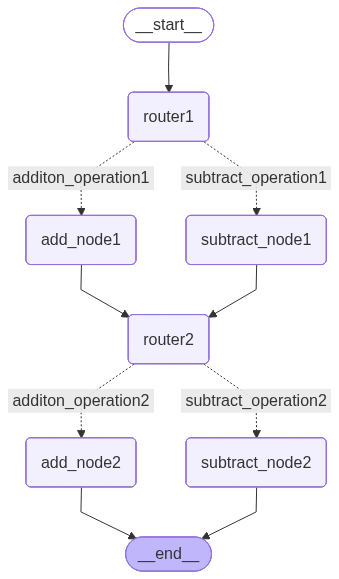

In [19]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [29]:
state_1 = AgentState(number1 = 10 , operation1 = "add" , number2 = 5 , number3 = 10 , operation2 = "add" , number4 = 323)
result1 = app2.invoke(state_1)
print(result1)

{'number1': 10, 'operation1': 'add', 'number2': 5, 'finalNumber1': 15, 'number3': 10, 'operation2': 'add', 'number4': 323, 'finalNumber2': 333}


In [30]:
print(result1['finalNumber1'])
print(result1['finalNumber2'])

15
333
